# Exercise 3 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: Emma Radoslavova Anastassova

Sciper number: 414901

#### Group Member 2:
Name: Mattea Busato

Sciper number: 408744

#### Group Member 3:
Name: Taliesin Perez

Sciper number: 357587

#### Group Member 4:
Name: Simon David Guillaume Jacques PIERRE

Sciper number: 345594

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

In [20]:
### Do the imports -- no need to change this
import numpy as np
from typing import List
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

# Ex 1: Prove of the Policy Gradient Theorem via the Performance Difference Lemma (20 points)

Denote $J(\pi) = \langle \mu, V^\pi \rangle$ and recall that the performance difference lemma states
$$
J(\pi) - J(\pi') = \frac{1}{(1-\gamma)}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]
$$
where $\lambda^{\pi'} \in \Delta_{\mathcal{S}\times\mathcal{A}}$ denotes the occupancy measure of the policy $\pi'$.

Now let us consider direct parametization, and compute a partial derivative for the entry of $\pi$ at index $(\bar{s},\bar{a})$:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}.
$$

**Questions**

To help you compute this partial derivative, consider the policies $\pi'$ parameterized by some (sufficiently small) $\delta \in \mathbb{R}$ via
$$
    \pi'(a|s) = \begin{cases}
        \pi(\bar{a}|\bar{s}) + \delta \quad (\text{if } (s,a)=(\bar{s},\bar{a}))\\
        \pi(a|s) \quad (\text{else})
    \end{cases}
$$

(1) Argue that
$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}.
$$

**Answer**

By definition, the partial derivative can be interpreted as the directional limit:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} 
= \lim_{\pi' \rightarrow \pi} \frac{J(\pi) - J(\pi')}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}
= \lim_{\delta \rightarrow 0} \frac{J(\pi) - J(\pi')}{-\delta}
$$

since $\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s}) = -\delta$ by construction, which goes to 0 as $\pi' \rightarrow \pi$, for $(s,a)$ fixed. By the Performance Difference Lemma, the numerator is:
$$
J(\pi) - J(\pi') = \frac{1}{1 - \gamma} \, \mathbb{E}_{s \sim \lambda^{\pi'}}\left[ \langle \pi(\cdot|s) - \pi'(\cdot|s), Q^\pi(s, \cdot) \rangle \right]
$$

and plugging this into our expression:


$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{1-\gamma} \lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle \pi(\cdot|s) - \pi'(\cdot|s), Q^\pi(s, \cdot) \rangle]}{-\delta} = \frac{1}{1-\gamma} \lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle \pi(\cdot|s) - \pi'(\cdot|s), Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}.
$$

(2) Argue that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).$$

Hint: Write the expectation in the previous question as a sum and use the fact that $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}}$.

**Answer**



Expanding as a sum:
$$
\mathbb{E}_{s \sim \lambda^{\pi'}}\left[ \langle \pi(\cdot|s) - \pi'(\cdot|s), Q^\pi(s, \cdot) \rangle \right] = \sum_{s \in \mathcal{S}} \lambda^{\pi'}(s) \sum_{a \in \mathcal{A}} \left( \pi(a|s) - \pi'(a|s) \right) Q^\pi(s,a).
$$

Since $\pi$ and $\pi'$ differ only at $(\bar{s}, \bar{a})$, the only non-zero term in this sum is for $s = \bar{s}$ and $a = \bar{a}$, so the expression for the expectation becomes:

$$
= \lambda^{\pi'}(\bar{s}) \cdot \left( \pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s}) \right) Q^\pi(\bar{s}, \bar{a}).
$$

Substituting this into the previous expression :

$$
\begin{aligned}
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}
& = \frac{1}{1-\gamma} \lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle \pi(\cdot|s) - \pi'(\cdot|s), Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} \\
&= \frac{1}{1 - \gamma} \lim_{\delta \rightarrow 0} \frac{ \lambda^{\pi'}(\bar{s}) \left( \pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s}) \right) Q^\pi(\bar{s}, \bar{a}) }{ \pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s}) } \\
&= \frac{1}{1 - \gamma} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).
\end{aligned}
$$


(3) Conclude that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$$
for the direct parameterization. 

**Answer**

We obtain the final result of the performance gradient under direct parametrization by taking the limit:
$$
\begin{aligned}
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}
&= \frac{1}{1 - \gamma} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}) \\
&= \frac{1}{1 - \gamma} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a})
\end{aligned}
$$

where we used the fact that
$$
\lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) = \lambda^{\pi}(\bar{s})
$$
since $\pi' \rightarrow \pi$ as $\delta \rightarrow 0$ and the occupancy measure $\lambda^{\pi'}$ depends continuously on the policy $\pi'$.

(4) Prove that for a general parametrization, it holds that
$$
\nabla_\theta J(\pi_\theta) = \frac{1}{(1-\gamma)} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} ( \log \pi_\theta(\bar{a}|\bar{s}))
$$

Hint: Use the chain rule to write $$ \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}), $$
and then use the fact that $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s}) \pi(\bar{a}|\bar{s})$.

**Answer**

Substituting the result of part (3) into the chain rule, then applying the log-derivative trick $\nabla_\theta \pi_\theta(\bar{a}|\bar{s}) = \pi_\theta(\bar{a}|\bar{s})\, \nabla_\theta \log \pi_\theta(\bar{a}|\bar{s})$ and the factorization $\lambda^\pi(\bar{s},\bar{a}) = \lambda^\pi(\bar{s})\,\pi(\bar{a}|\bar{s})$, we prove that the expression holds:

$$
\begin{aligned}
\nabla_\theta J(\pi_\theta) 
&= \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}) \\
&= \frac{1}{1-\gamma} \sum_{\bar{s},\bar{a}} \lambda^\pi(\bar{s})\, Q^\pi(\bar{s},\bar{a})\, \nabla_\theta \pi_\theta(\bar{a}|\bar{s}) \\
&= \frac{1}{1-\gamma} \sum_{\bar{s},\bar{a}} \lambda^\pi(\bar{s},\bar{a})\, Q^\pi(\bar{s},\bar{a})\, \nabla_\theta \log \pi_\theta(\bar{a}|\bar{s})
\end{aligned}
$$

# Ex 2: Natural Policy Gradient with softmax parameterization (20 points)

Recall that the iterates $\{\pi^t\}^{\infty}_{t=1}$ produced by NPG read as follows:
$$
\pi^{t+1}(a|s) = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
$$

Implement NPG for an arbitrary step size $\eta$. Please note that $e^{\eta Q^{\pi^t}(s,a)}$ can be zero, account for that in your implementation.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [68]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy stochastic passed with shape n_states times n_actions
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s].dot(pi[s])
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

def npg_update(q, eta, old_policy):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        new_policy: the updates policy
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        logits = np.log(np.clip(old_policy[s], 1e-30, 1.0)) + eta * q[s]                                                                                                                                                 
        max_logit = np.max(logits)
        policy[s] = np.exp(logits - max_logit) # TODO (unnormalized update)
        total = np.sum(policy[s])
        if total == 0:
             policy[s] = np.ones(q.shape[1])/q.shape[1]
        else:
            policy[s] = policy[s] / total # TODO: normalize
    return policy

def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s,np.argmax(q[s,:])] = 1
    return policy

In [69]:
def NPG(env, eta): # apply NPG iterations for 30 steps
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.ones_like(q)/env.n_actions
    for k in range(30):
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env)
        if eta < np.inf:
            pi = npg_update(q, eta, pi)
        else:
            pi = get_greedy_policy(q)
        vs.append(v)
        policies.append(pi)
    return vs, policies

Now, we run NPG for different stepsizes in the usual gridworld environment

In [81]:
reward_mode = 2
size = 10 
prop = 0
gamma=0.99
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
mu = np.ones(gridworld.n_states)/gridworld.n_states
etas = [1e-3, 1e-2, 1e-1, 1, 100, 1e7, np.inf]
v_different_etas = []
pi_different_etas = []
for eta in etas:
    values_pi, policies = NPG(gridworld, eta=eta)
    v_different_etas.append(values_pi)
    pi_different_etas.append(policies)

In [82]:
solver = MDPsolver(gridworld)
solver.value_iteration()

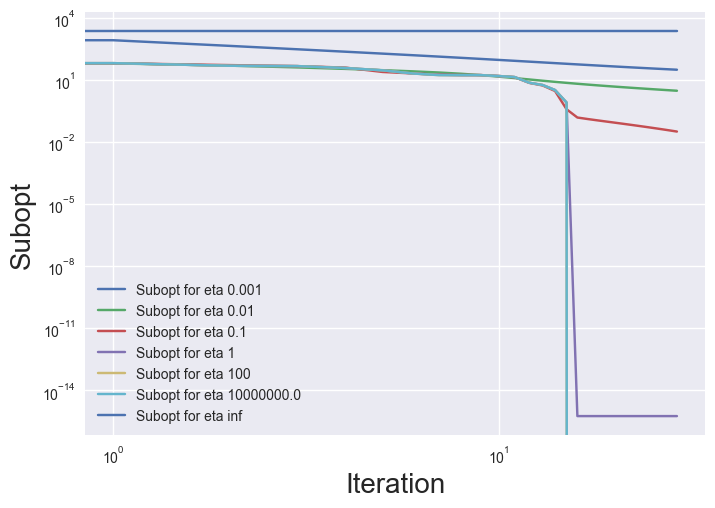

In [83]:
# TODO: if this plot appears with a too large legend, rerun this line once more
plot_log_lines([np.array([mu.dot(solver.v - v) for v in v_different_etas[i]]) for i, _ in enumerate(etas)], [f"Subopt for eta {eta}" for eta in etas], ["Iteration", "Subopt"], "figs", "NPG.pdf", show = True)

**Question**

Show that NPG with $\eta = \infty$ coincides with Policy Iteration (PI).

More formally: Assuming that $a^\star_s := \mathrm{argmax}_a Q^{\pi^t}(s,a)$ is unique for all $s$, prove that $$ \lim_{\eta \rightarrow \infty} \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \begin{cases} 1 \quad \text{if} \quad a = a^\star_s \\ 0 \quad \text{otherwise} \end{cases},$$
and explain how this relates to PI.

**Answer**

We rewrite the exponential as $e^{\eta (Q^{\pi^t}(s,a) - Q^{\pi^t}(s,a^\star_s) + Q^{\pi^t}(s,a^\star_s))}$ and factor out $e^{\eta Q^{\pi^t}(s, a^\star_s)}$ from both the numerator and the denominator, where $a^\star_s := \arg\max_a Q^{\pi^t}(s, a)$ is unique by assumption:

$$
\begin{aligned}
\pi^{t+1}(a|s) 
&= \frac{\pi^t(a|s)\, e^{\eta Q^{\pi^t}(s,a)}}{\sum_{a'} \pi^t(a'|s)\, e^{\eta Q^{\pi^t}(s,a')}}
= \frac{\pi^t(a|s)\, e^{\eta (Q^{\pi^t}(s,a) - Q^{\pi^t}(s,a^\star_s) + Q^{\pi^t}(s,a^\star_s))}}{\sum_{a'} \pi^t(a'|s)\, e^{\eta (Q^{\pi^t}(s,a') - Q^{\pi^t}(s,a^\star_s) + Q^{\pi^t}(s,a^\star_s))}} \\
&= \frac{\pi^t(a|s)\, e^{\eta (Q^{\pi^t}(s,a) - Q^{\pi^t}(s,a^\star_s))}}{\sum_{a'} \pi^t(a'|s)\, e^{\eta (Q^{\pi^t}(s,a') - Q^{\pi^t}(s,a^\star_s))}}.
\end{aligned}
$$

We look at this expression in both cases $a = a^\star_s$ and $a \neq a^\star_s$ and take the limit $\eta \rightarrow \infty$. 

For $a = a^\star_s$, the exponent in the numerator is $\eta(Q^{\pi^t}(s,a^\star_s) - Q^{\pi^t}(s,a^\star_s)) = 0$, so the numerator equals $\pi^t(a^\star_s|s)$. In the denominator, the term corresponding to $a' = a^\star_s$ also equals $\pi^t(a^\star_s|s)$, while every term with $a' \neq a^\star_s$ has a strictly negative exponent $\eta(Q^{\pi^t}(s,a') - Q^{\pi^t}(s,a^\star_s)) < 0$ (by uniqueness of the maximizer), so it goes to zero as $\eta \to \infty$. The denominator therefore converges to $\pi^t(a^\star_s|s)$ and the limit equals $\pi^t(a^\star_s|s) / \pi^t(a^\star_s|s) = 1$.

For $a \neq a^\star_s$, the exponent in the numerator is $\eta(Q^{\pi^t}(s,a) - Q^{\pi^t}(s,a^\star_s)) < 0$ so it goes to $-\infty$ as $\eta \to \infty$ and the numerator goes to zero. The denominator is bounded from below by the $a' = a^\star_s$ term, which equals $\pi^t(a^\star_s|s) > 0$, so the limit of the ratio converges to $0$. Therefore

$$
\lim_{\eta \rightarrow \infty} \pi^{t+1}(a|s) = \begin{cases} 1 & \text{if } a = a^\star_s, \\ 0 & \text{otherwise,} \end{cases}
$$

which is precisely the greedy policy improvement step of PI. Therefore NPG with $\eta = \infty$ exactly reproduces the greedy policy update of PI.

**Question**

Is this observation in line with the empirical results in the plot above? I.e., is the plot for $\eta = \infty$ as you would expect it for PI?

**Answer**

Yes, the empirical results are consistent with the theoretical expectations. As seen in the lecture, the tabular NPG policy update under softmax parameterization is
$$\pi_{t+1}(a \mid s) = \pi_t(a \mid s) \frac{\exp\!\left(\frac{\eta}{1-\gamma} A^{\pi_t}(s,a)\right)}{Z_t(s)}$$

and as $\eta \to \infty$, all probability mass concentrates on the action (assuming uniqueness as in the previous question) maximizing
$A^{\pi_t}(s, \cdot)$ at each state $s$. Since $A^{\pi_t}(s,a) = Q^{\pi_t}(s,a) - V^{\pi_t}(s)$
and $V^{\pi_t}(s)$ does not depend on $a$, this is the same as selecting
$\operatorname{arg\,max}_{a} Q^{\pi_t}(s,a)$, which is precisely the greedy policy improvement
step that PI takes after exact
policy evaluation. In the known-model setting,
$A^{\pi_t}$ is computed exactly, hence NPG with $\eta = \infty$ is identical to PI.

In the plot, the $\eta = \infty$ curve behaves exactly as what we saw for PI in assignment 1: it exibits a sharp drop before reaching near-zero (up to numerical precisaion) suboptimality. Here, the drop happens at around the 9th iteration. Since the number of deterministic
policies is finite and each greedy step strictly increases $J(\pi_t)$ or has reached $\pi^\star$,
PI cannot cycle and terminates in finitely many steps, in particular, with worst-case bound
$\mathcal{O}\!\left(\frac{|\mathcal{S}|(|\mathcal{A}|-1)}{1-\gamma}\right)$.As we explained in our solutions in assignment 1, this bound is usually very loose and PI typically converges much faster in practice.

The other curves are also consistent: for large $\eta$, they closely track the $\eta = \infty$ curve since the
update nearly concentrates on the greedy action, while small $\eta$ leads to slow convergence
as the policy changes only slightly at each step.

## Ex 2.2 Slow Changing Property of NPG

In this exercise you will investigate by how much consecutive iterates $\pi^t$ and $\pi^{t+1}$ produced by NPG differ and how this distance is controlled by the step size $\eta$.

Plot $$\max_{s \in \mathcal{S}} || \pi^{t+1}(a|s) - \pi^t(a|s) ||_1$$ for different values of $\eta$.

In [78]:
def compute_policy_variation(policies):
    variation = []
    for pi, pip in zip(policies[1:], policies[:-1]):
        variation.append(np.max([np.sum(np.abs(pip[s] - pi[s])) for s in range(pi.shape[0])])) # TODO
    return variation

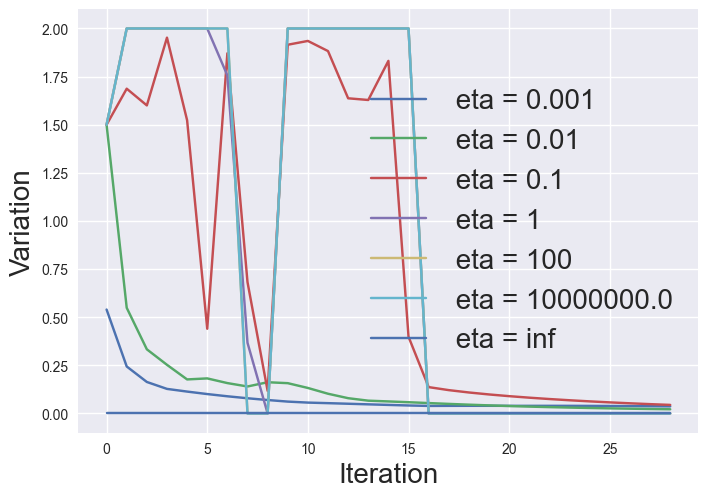

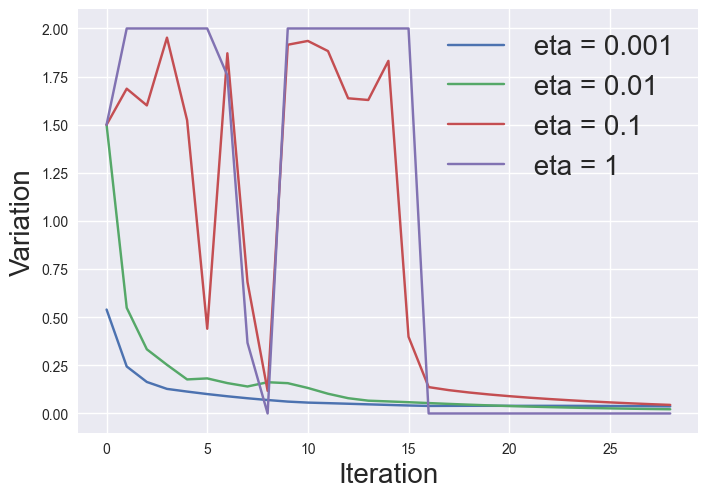

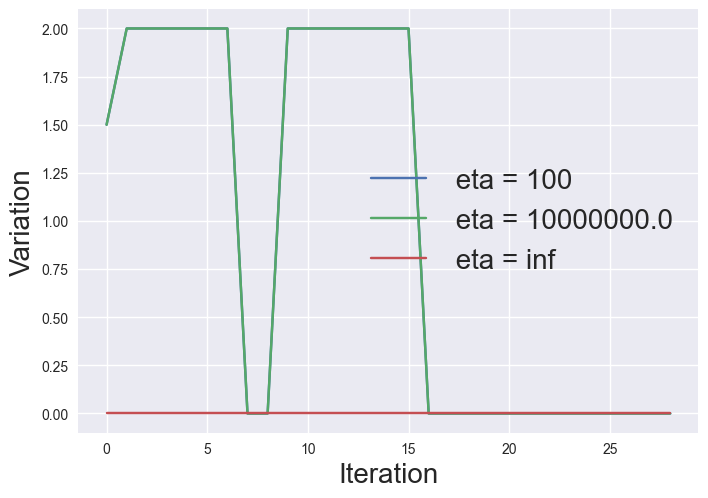

In [80]:
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)]), 
               [f" eta = {eta}" for eta in etas], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)

# small etas (for better visualization)
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)])[:4], 
               [f" eta = {eta}" for eta in etas[:4]], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)


# large 
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)])[4:], 
               [f" eta = {eta}" for eta in etas[4:]], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)

In [97]:
# numerical check
for eta, policies in zip(etas, pi_different_etas):
    pi_1 = np.array(policies[1])  # policy at iteration 1 for this eta
    n_deterministic_states = np.sum(np.max(pi_1, axis=1) == 1.0)
    
    print(f"\neta = {eta}")
    print(f"global min probability at iteration 1, across all states: {np.min(pi_1)}")
    print(f"global max probability at iteration 1, across all states: {np.max(pi_1)}")
    print(f"number of deterministic states: {n_deterministic_states}")

    for s in range(10): # we check the policies for the first 10 states
        state_policy = pi_1[s]
        print(f"state {s}: policy = {state_policy} \nmin = {np.min(state_policy)}, max = {np.max(state_policy)}")


eta = 0.001
global min probability at iteration 1, across all states: 0.121405829926975
global max probability at iteration 1, across all states: 0.5199374839779036
number of deterministic states: 0
state 0: policy = [0.25 0.25 0.25 0.25] 
min = 0.25, max = 0.25
state 1: policy = [0.21216213 0.12140583 0.14649456 0.51993748] 
min = 0.121405829926975, max = 0.5199374839779036
state 2: policy = [0.23657337 0.15749275 0.19251132 0.41342256] 
min = 0.15749275329616222, max = 0.41342255984235704
state 3: policy = [0.24508551 0.18083322 0.20593287 0.3681484 ] 
min = 0.18083321877286712, max = 0.3681483982679401
state 4: policy = [0.24959962 0.21927014 0.19284476 0.33828547] 
min = 0.19284476473498063, max = 0.33828547337515713
state 5: policy = [0.25331575 0.25968209 0.19864774 0.28835442] 
min = 0.19864773509811431, max = 0.288354424087229
state 6: policy = [0.25501656 0.2702389  0.22597993 0.24876461] 
min = 0.22597993230995722, max = 0.2702389023736028
state 7: policy = [0.25505765 0.268

**Question**

Empirically, is the largest change (among all iterations) between consecutive iterations is larger for smaller or large values of $\eta$?

**Answer:**

Empirically, the largest change between consecutive iterations occurs for larger values of $\eta$.

For $\eta = \infty$ (PI), the variation $\max_s \|\pi^{t+1}(\cdot|s) - \pi^t(\cdot|s)\|_1$ equals 2 for the early iterations, which is because PI produces a deterministic greedy policy at each step and whenever the greedy action changes between iterations for some state $s$, the two consecutive policies have disjoint support, giving the maximum L1 distance of 2. Similarly, $\eta = 10^7$ approximates the greedy limit and behaves similarly to $\eta = \infty$.

For finite $\eta$, the softmax update $\pi^{t+1}(a|s) \propto \pi^t(a|s)e^{\eta Q^{\pi^t}(s,a)}$ guarantees full support in theory, so the variation should never reach exactly 2. However, by doing a simple numerical check (see above) we see that for $\eta \geq 1$, for a lot of states the policies already concentrate all mass on a single action after the very first update, making them effectively deterministic. This explains why the variation reaches 2 even for finite $\eta$ in the plot.

For smaller $\eta$, the update is more conservative: the policy changes only slightly at each iteration and the variation decreases smoothly, consistent with the bound $\frac{\eta}{1-\gamma}$ proven below. The numerical check at iteration 1 confirms this: for $\eta = 0.001$ no state is deterministic and the maximum probability across all states is only $0.52$, while for $\eta = 0.01$ the policy is already nearly concentrated in some states (max probability $\approx 0.9999$). From $\eta = 1$ onward most states become numerically deterministic after a single update (68, 88, 88 and 100 deterministic states for $\eta = 1, 100, 10^7, \infty$ respectively), confirming that larger $\eta$ makes the NPG updat increasingly close to the greedy PI step.

## Some Theory to Motivate the Observation Above

**Question**

Our goal is to prove that $$ || \pi^{t+1}(\cdot|s) - \pi^t(\cdot|s) ||_1 \leq \frac{\eta}{1 - \gamma} \quad \forall s \in \mathcal{S}, \forall t \in [T].$$

We guide you towards this result by breaking the proof into small steps.

1) Prove that $$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log \bigg(\sum_{a'\in\mathcal{A}} \pi^t(a'|s) \exp (\eta Q^{\pi^t}(s,a'))\bigg) $$

Hint: First apply Pinkser's inequality https://en.wikipedia.org/wiki/Pinsker%27s_inequality to prove that $$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq KL(\pi^{t+1}(s)||\pi^t(s)), $$ then plug in the formula for $\pi^{t+1}$ into the KL term.

**Answer**

We use Pinsker's inequality: for any two distributions $p, q$:                                                                                                                                                   
$$
\frac{1}{2}\|p - q\|_1^2 \leq \mathrm{KL}(p \| q).$$                                                                                                                                                           
Applying this with $p = \pi^{t+1}(\cdot|s)$ and $q = \pi^t(\cdot|s)$, it suffices to bound the KL term. Let $Z_s := \sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}$. By definition of KL:                        
$$
\mathrm{KL}(\pi^{t+1} \| \pi^t) = \sum_a \pi^{t+1}(a|s) \log \frac{\pi^{t+1}(a|s)}{\pi^t(a|s)}.$$                                                                                                            

Substituting the NPG update $\pi^{t+1}(a|s) = \frac{\pi^t(a|s) e^{\eta Q^{\pi^t}(s,a)}}{Z_s}$ into the log ratio gives $\log \frac{\pi^{t+1}(a|s)}{\pi^t(a|s)} = \eta Q^{\pi^t}(s,a) - \log Z_s$, so:            
$$
\mathrm{KL}(\pi^{t+1} \| \pi^t) = \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log Z_s,$$     

where we used $\sum_a \pi^{t+1}(a|s) = 1$. Combined with Pinsker's inequality:                                                                                                                                   
$$
\frac{1}{2}\|\pi^{t+1}(\cdot|s) - \pi^t(\cdot|s)\|_1^2 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log\!\left(\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}\right)
$$

2) Prove that 
$$
\sum_{a\in \mathcal{A}} \pi^{t+1}(a|s) \exp(- \eta Q^{\pi^t}(s,a)) = \frac{1}{\sum_{a'\in \mathcal{A}} \pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a) )}.
$$

**Answer**

Starting from the NPG update, we multiply both sides by $e^{-\eta Q^{\pi^t}(s,a)}$:
$$\pi^{t+1}(a|s)\, e^{-\eta Q^{\pi^t}(s,a)} = \frac{\pi^t(a|s)}{Z_s}$$

Summing over all $a \in \mathcal{A}$ and using $\sum_a \pi^t(a|s) = 1$:

$$\sum_{a \in \mathcal{A}} \pi^{t+1}(a|s)\, e^{-\eta Q^{\pi^t}(s,a)} = \frac{1}{Z_s} = \frac{1}{\sum_{a'} \pi^t(a'|s)\, e^{\eta Q^{\pi^t}(s,a')}}$$

3) Using the results in 1) and 2) prove that 

$$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] + \log \bigg(\sum_{a'\in\mathcal{A}} \pi^{t+1}(a'|s) \exp (-\eta Q^{\pi^t}(s,a'))\bigg). $$

**Answer**

From step 1) we have:
$$
\frac{1}{2}\|\pi^{t+1} - \pi^t\|_1^2 \leq \mathbb{E}_{a \sim \pi^{t+1}}[\eta Q^{\pi^t}(s,a)] - \log Z_s
$$
From step 2), taking the log of the identity gives $\log\!\left(\sum_{a'} \pi^{t+1}(a'|s)\, e^{-\eta Q^{\pi^t}(s,a')}\right) = -\log Z_s$. Substituting directly:

$$
\frac{1}{2}\|\pi^{t+1}(\cdot|s) - \pi^t(\cdot|s)\|_1^2 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] + \log\!\left(\sum_{a'} \pi^{t+1}(a'|s)\, e^{-\eta Q^{\pi^t}(s,a')}\right)
$$ 

4) Using Hoeffding's Lemma https://en.wikipedia.org/wiki/Hoeffding%27s_lemma (on the sum in the log term!) and the fact that $$-\frac{1}{1-\gamma} \leq Q^{\pi^t}(s,a) \leq \frac{1}{1-\gamma},$$ conclude that 
$$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \frac{\eta^2}{2 (1 - \gamma)^2}.$$

**Answer**

We apply Hoeffding's Lemma to the log-sum term from step 3). 
Define $X = -Q^{\pi^t}(s,a)$ with $a \sim \pi^{t+1}(\cdot|s)$. From the bound on $Q^{\pi^t}$, we have $X \in \left[-\frac{1}{1-\gamma}, \frac{1}{1-\gamma}\right]$, so the range is $b - a = \frac{2}{1-\gamma}$ and $(b-a)^2 = \frac{4}{(1-\gamma)^2}$.

Hoeffding's Lemma states that for any real-valued RV $X$ such that $X \in [a,b]$ a.s. and $\forall \lambda \in \mathbb R$:
$$
\mathbb{E}\!\left[e^{\lambda X}\right] \leq \exp \left( \lambda\,\mathbb{E}[X] + \frac{\lambda^2(b-a)^2}{8} \right)
$$ 
or equivalently by applying $\log$ to both sides:
$$
\log \mathbb{E}\!\left[e^{\lambda X}\right] \leq \lambda\,\mathbb{E}[X] + \frac{\lambda^2(b-a)^2}{8}
$$ 

Applying this with $\lambda = \eta$ to $\log\!\left(\sum_{a'} \pi^{t+1}(a'|s)\, e^{-\eta Q^{\pi^t}(s,a')}\right) = \log \mathbb{E}_{a \sim \pi^{t+1}}\!\left[e^{\eta X}\right]$:
$$\log\!\left(\sum_{a'} \pi^{t+1}(a'|s)\, e^{-\eta Q^{\pi^t}(s,a')}\right) \leq -\eta\,\mathbb{E}_{a \sim \pi^{t+1}}[Q^{\pi^t}(s,a)] + \frac{\eta^2}{2(1-\gamma)^2}.$$

Substituting into step 3), the $\mathbb{E}[Q^{\pi^t}]$ terms cancel:
$$
\frac{1}{2}\|\pi^{t+1}(\cdot|s) - \pi^t(\cdot|s)\|_1^2 \leq \frac{\eta^2}{2(1-\gamma)^2}
$$
which gives $\|\pi^{t+1}(\cdot|s) - \pi^t(\cdot|s)\|_1 \leq \frac{\eta}{1-\gamma}$ for all $s \in \mathcal{S}$ and all $t$.

# Ex 3: OPPO: The importance of Exploration in Policy Gradient (20 points)

In this exercise, we will investigate how crucial it is to perform exploration. That is, adding bonuses to avoid suffering the mismatch coefficients in the convergence bounds.

Let us recall that the standard sample based version of NPG suffers the mismatch coeffcients in the bounds (see Slide 22 in Lecture 5). Those are avoided by OPPO ( See slide 30 in Lecture 5 ).

**To see clearly the advatange of OPPO we will consider an MDP with unbounded mismatch coefficients**

**Question: example of unbounded mismatch coefficients**

Consider a 10 x 10 gridworld, the initial state is always the bottom right corner, i.e. the initial distribution $\mu$ equals $1$ at this starting state and it is zero everywhere else. Can you compute a finite bound for 
$$\max_\pi \max_{s \in \mathcal{S}} \bigg |\frac{\lambda^\pi(s)}{\mu(s)} \bigg|,$$
i.e. the mismatch coefficient? If not, argue for which reason.

**Answer**



No, it is not possible to compute a finite bound for the mismatch coefficient, since the initial distribution $\mu$ is a point mass at $s_0 = 99$ and hence $\mu(s) = 0$ for all $s \neq s_0$. However the ratio $\lambda^\pi(s)/\mu(s)$ is undefined (division by 0) whenever $\lambda^\pi(s) > 0$ for any $s \neq s_0$. Since the gridworld is fully connected, there always exists a policy $\pi$ that visits any state $s \neq s_0$ with positive probability, making $\lambda^\pi(s) > 0$. Taking the max over all such $s$ and $\pi$:

$$\max_\pi \max_{s \in \mathcal{S}} \left|\frac{\lambda^\pi(s)}{\mu(s)}\right| = \infty$$

In the following, we experiment with OPPO with and without bonuses in this environment.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [98]:
reward_mode = 0
size = 10
gamma=0.999
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

In [49]:
# option 1
from copy import deepcopy
np.random.seed(0)
def oppo(K: int = 10000, H: int = 20, beta: float = 0.0001, eta=5) -> List[float]:
    """
    Function implementing OPPO with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param beta: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    policy = H * np.ones((H, gridworld.n_states, gridworld.n_actions))/gridworld.n_actions
    V[H, :] = 0
    estimated_transitions = np.ones((H, gridworld.n_states, 
                                     gridworld.n_actions, 
                                     gridworld.n_states))/gridworld.n_states
    N = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    bonus = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    N_next = np.zeros((H, gridworld.n_states, gridworld.n_actions, gridworld.n_states))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):
            #NPG Update
            q_shifted = Q[h, state, :] - np.max(Q[h, state, :])
            policy[h, state, :] = policy[h, state, :] * np.exp(eta * q_shifted)  # TODO (unnormalized)
            
            total = np.sum(policy[h, state, :])
            if total == 0 or np.any(np.isnan(policy[h, state, :])):
                policy[h, state, :] = np.ones(gridworld.n_actions) / gridworld.n_actions  # TODO: fallback to a uniform distribution
            else:
                policy[h, state, :] = policy[h, state, :] / total  # TODO: normalize

            # Sample one action the current policy
            a = np.random.choice(gridworld.n_actions, p=policy[h, state, :])  # TODO
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1  # TODO

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])
            N_next[h, state, a, new_state] += 1  # TODO
            
            # Update empirical transition estimate
            estimated_transitions[h, state, a, :] = N_next[h, state, a, :] / (N[h, state, a] + 1)  # TODO
            state = new_state
                    
        # Calculate the UCB bonus
        bonus = beta * np.sqrt(1.0 / np.maximum(N, 1))

        Q_new = np.zeros_like(Q)
        V_new = np.zeros_like(V)
        for h in reversed(range(H)):  # Step loop
            # Update Q according to the algorithm
            transition_value = np.array([[np.sum(estimated_transitions[h, s, a, :] * V_new[h + 1, :]) for a in range(gridworld.n_actions)] for s in range(gridworld.n_states)])
            Q_new[h] = np.clip(gridworld.r + bonus[h] + transition_value, 0, H - h) # TODO

            # Update V as the Q-value of the optimal actions for the current state
            for state in range(gridworld.n_states):
                V_new[h, state] = np.dot(policy[h, state, :], Q_new[h, state, :])  # TODO
        Q = deepcopy(Q_new)
        V = deepcopy(V_new)
    return rewards

In [ ]:
# option 2
from copy import deepcopy
np.random.seed(0)
def oppo(K: int = 10000, H: int = 20, beta: float = 0.0001, eta=5) -> List[float]:
    """
    Function implementing OPPO with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param beta: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    policy = H * np.ones((H, gridworld.n_states, gridworld.n_actions))/gridworld.n_actions
    V[H, :] = 0
    estimated_transitions = np.ones((H, gridworld.n_states, 
                                     gridworld.n_actions, 
                                     gridworld.n_states))/gridworld.n_states
    N = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    bonus = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    N_next = np.zeros((H, gridworld.n_states, gridworld.n_actions, gridworld.n_states))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):
            #NPG Update
            q_shifted = Q[h, state, :] - np.max(Q[h, state, :])
            policy[h, state, :] = policy[h, state, :] * np.exp(eta * q_shifted)  # TODO (unnormalized)
            
            total = np.sum(policy[h, state, :])
            if total == 0 or np.any(np.isnan(policy[h, state, :])):
                policy[h, state, :] = np.ones(gridworld.n_actions) / gridworld.n_actions  # TODO: fallback to a uniform distribution
            else:
                policy[h, state, :] = policy[h, state, :] / total  # TODO: normalize

            # Sample one action the current policy
            a = np.random.choice(gridworld.n_actions, p=policy[h, state, :])  # TODO
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1  # TODO

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])
            N_next[h, state, a, new_state] += 1  # TODO
            
            # Update empirical transition estimate
            estimated_transitions[h, state, a, :] = N_next[h, state, a, :] / (N[h, state, a] + 1)  # TODO
            state = new_state
                    
        # Calculate the UCB bonus
        bonus = beta * np.sqrt(1.0 / np.maximum(N, 1))

        Q_new = np.zeros_like(Q)
        V_new = np.zeros_like(V)
        for h in reversed(range(H)):  # Step loop
            # Update Q according to the algorithm
            transition_value = np.einsum("san,n->sa", estimated_transitions[h], V_new[h + 1])
            Q_new[h] = np.clip(gridworld.r + bonus[h] + transition_value, 0, H - h) # TODO

            # Update V as the Q-value of the optimal actions for the current state
            for state in range(gridworld.n_states):
                V_new[h, state] = np.dot(policy[h, state, :] / np.sum(policy[h, state, :]), Q_new[h, state, :])  # TODO
        Q = deepcopy(Q_new)
        V = deepcopy(V_new)
    return rewards

In [46]:
to_plot = []
betas = [0, 1e-5, 1e-3, 0.1, 10]

for beta in betas:
    print(beta)
    reward_OPPO = oppo(beta = beta)  # You can play around with the arguments if you like
    to_plot.append(np.cumsum(reward_OPPO))

0
1e-05
0.001
0.1
10


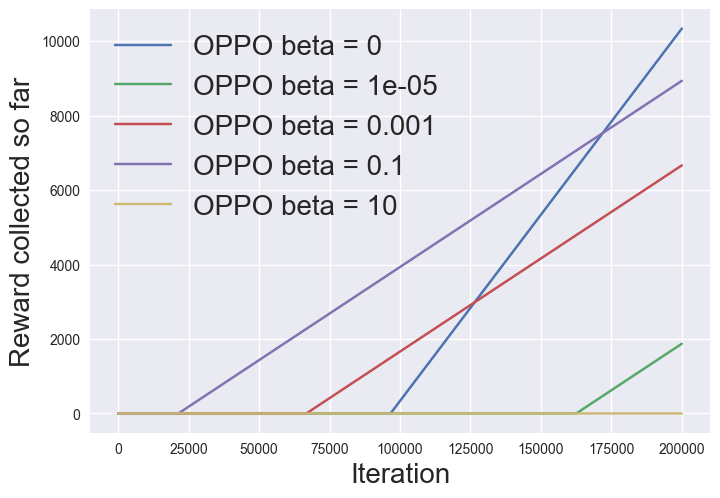

In [48]:
labels = [ f"OPPO beta = {beta}" for beta in betas]
plot_lines(
    to_plot[:],
    labels[:],
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=False
)

**Question**

Why does setting $\beta = 0$ lead to bad results? 

*Hint: Explain using the remarks in slide 28 and the theoretical bound in Slide 22 of Lecture 5*.

**Answer**

Setting $\beta=0$ removes all exploration bonus, hence OPPO no longer uses optimistic $Q$-values and is reduced to the standard sample-based NPG, with convergence bound:
$$\mathbb{E}\left[\min_{t\leq T} J(\pi_{\theta^\star}) - J(\pi_{\theta_t})\right] \leq \mathcal{O}\left(\frac{1}{1-\gamma}\sqrt{\frac{2\log|A|}{T}} + \sqrt{\kappa\,\varepsilon_\text{stat}} + \sqrt{\varepsilon_\text{bias}}\right)$$

Since $\mu$ is a point mass at $s_0=99$ in this gridworld, we have $\mu(s)=0$ for all $s\neq s_0$ and hence $\kappa = \|\lambda^{\pi^\star}_\mu / \mu\|_\infty = \infty$ for any optimal policy that visits states beyond $s_0$, meaning the bound gives no useful guarantee.

Without bonuses, the Q-values for unvisited states and actions are not encouraged, so the policy has no incentive to explore beyond what it can reach from $s_0$ and the algorithm may fail to explore the parts of the grid where the reward is located. Since the reward is placed far from the starting corner, the agent never discovers it, which we confirm from the flat $\beta=0$ curve, showing that we get zero cumulative reward.

**Question**

Why does setting $\beta$ too large lead to poor results?

*Hint: Answer using the regret bound for OPPO given at the beginning of slide 30.*

**Answer**

The OPPO regret bound is:
$$\sum_{t=1}^T V^\star(s_1) - V^{\pi^t}(s_1) \leq \mathcal{O}\!\left(\sum_{h=1}^H\sum_{t=1}^T \mathrm{bonus}_h^t(s_h^t, a_h^t)\right)$$

which grows linearly with $\beta$ since $\text{bonus}^t_h(s,a) = \beta H / \sqrt{N^t_h(s,a)+1}$ hence for large $\beta$, the bonus term can dominate the Q-update $Q_h = r + \mathrm{bonus} + \hat{P}V$.
In that case, the policy is influenced more by the exploration bonus than by the actual rewards of the MDP. As a result, the agent ends up ends up focusing exclusively on selecting uncertain, i.e unfrequently visited state-action pairs instead of exploiting high-reward actions.

We confirm this visually in the plot, where the curve for the cumulative reward for $\beta=10$ is flat at 0. We conclude that there is a tradeoff between exploration and exploitation: a positive bonus is useful because it encourages exploration of uncertain, less visited state-action pairs, but if $\beta$ is too large, the algorithm over-explores and ends up ignoring the true reward signal. Therefore a middle-ground solution for the $\beta$ ends up leading to the optimal solutions.

# Ex 4: REINFORCE with parametrized policies (20 points)

In this exercise, we will investigate the effect of choosing different baselines in the reinforce implementation.
This topic is covered from Slide 31 on in Lecture 5.

**Hint: You may want to use Google Colab to run the experiments faster, but you don't have to.**

### Import the Necessary Packages

In [102]:
# TODO: you may need to run this to make sure to have the correct versions
!pip install gym==0.25.2
!pip install gym-notices==0.0.8


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [103]:
import gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [104]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

In [105]:
env = gym.make('CartPole-v0')
env.seed(0)

/Users/emma.anastassova/Documents/EPFL/courses/Reinforcement Learning/reinforcementlearning_ee568/venv_rl/lib/python3.14/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/emma.anastassova/Documents/EPFL/courses/Reinforcement Learning/reinforcementlearning_ee568/venv_rl/lib/python3.14/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/emma.anastassova/Documents/EPFL/courses/Reinforcement Learning/reinforcementlearning_ee568/venv_rl/lib/python3.14/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` 

[0]

In [106]:
class Policy(nn.Module): # definie the policy network
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        return F.softmax(x, dim=1) # we just consider 1 dimensional probability of action

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)
    

In [107]:
# REINFORCE (with reward-to-go)
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

**Question**

1. Find **two** good baselines that improve over the implementation of REINFORCE without baseline. You should plot their results below.

You can take inspiration from the Example Notebook we attached for lecture 4, but you **cannot use exactly the same**.

2. Explain why you chose your baselines and why you think they are reasonable.

*Note:* You may also change other parameters such as the learning rate, as long as you clearly state it in your response.

**Answer**

In [ ]:
def naive_baseline(state): # Example Baseline from lecture 4 (for inspiration)
  angle = state[2]
  value = 100*(0.25-angle**2) # TO BE CHANGED USING YOUR BASELINE
  return value

def baseline_1(state): # TO BE CHANGED USING YOUR BASELINE 1
  ???   # TODO
  return ??? # TODO

def baseline_2(state): # TO BE CHANGED USING YOUR BASELINE 2
  ???   # TODO
  return ??? # TODO

# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

In [ ]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 1: run REINFORCE
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 2: run REINFORCE and YOUR baseline 1
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(policy_baseline_1, optimizer_baseline_1, baseline=baseline_1, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 3: run REINFORCE and YOUR baseline 2
policy_baseline_2 = Policy().to(device)
optimizer_baseline_2 = optim.Adam(policy_baseline_2.parameters(), lr=1e-2)
scores_baseline_2 = reinforce_rwd2go_baseline(policy_baseline_2, optimizer_baseline_2, baseline=baseline_2, early_stop=False, n_episodes=2000)



In [ ]:
### Plot the learning progress

# Create the plot
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Plot the scores with specified colors and labels
ax.plot(np.arange(1, len(scores_rwd2go) + 1), scores_rwd2go, color='green', label='No Baseline')
ax.plot(np.arange(1, len(scores_baseline_1) + 1), scores_baseline_1, color='blue', label='Baseline 1')
ax.plot(np.arange(1, len(scores_baseline_2) + 1), scores_baseline_2, color='red', label='Baseline 2')

# Set the labels with a larger font size
ax.set_ylabel('Total reward (= time balanced)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)

# Set the tick labels to a larger font size
ax.tick_params(axis='both', which='major', labelsize=15)

# Add a legend with a specified font size
ax.legend(fontsize=20)

# Show the plot
plt.show()

# $Q^\star$: Policy Gradient with continuous actions and bound on the bonuses count in OPPO (20 points)
***Question 1:*** Consider using a Gaussian parameterized policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathrm{R}^d$ 
and covariance matrix $\Sigma$ . Write down the following gradients:

$$ \nabla_\mu J(\pi_{\mu, \Sigma}) = ???$$
$$ \nabla_\Sigma J(\pi_{\mu, \Sigma}) = ???$$
***Question 2*** In this exercise, you will bound the state action counts. This is a crucial part of the OPPO convergence proof. Let $N^t_h(s,a)$ denotes the number of times the state action pair $s,a$ has been visited at step $h$ in all the episode up to $t$ included. Moreover,
let $s^t_h,a^t_h$ be the state action pair visited at step $h$ of the $t^{th}$ episode. Then, prove that 
$$ \sum^T_{t=1} \sum^H_{h=1} \frac{1}{N^t_h(s^t_h, a^t_h)+1} \leq SAH \log( T H)$$
***Question 3*** Use the fact above to prove the following bound at slide 30 of Lecture 5. That is, for $\mathrm{bonus}^t_h(s,a) = \frac{H}{\sqrt{N^t_h(s,a)+1}}$ it holds that
$$ \sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) \leq \sqrt{ H^3 SA T \log( T H)}$$